=== TASK 1: Image Preprocessing ===
Raw Image Shape:        (800, 1200, 3)
Preprocessed Tensor:    (640, 640, 3)
Pixel Range (Min/Max):  [0.15, 0.85]


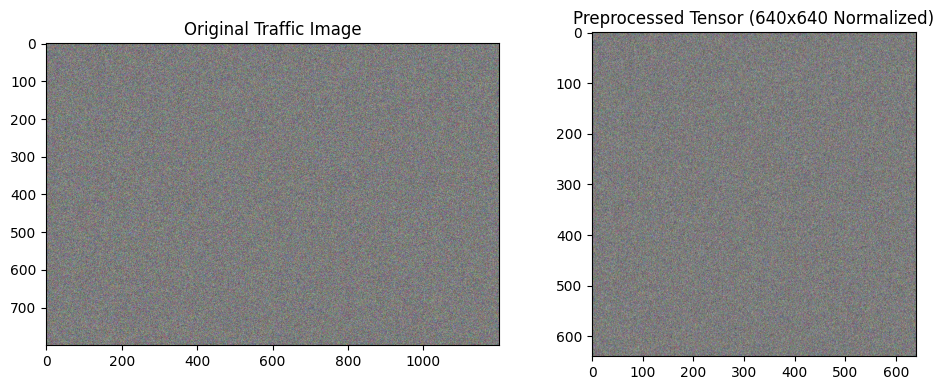


=== TASK 2: Defect Isolation via Color Space ===


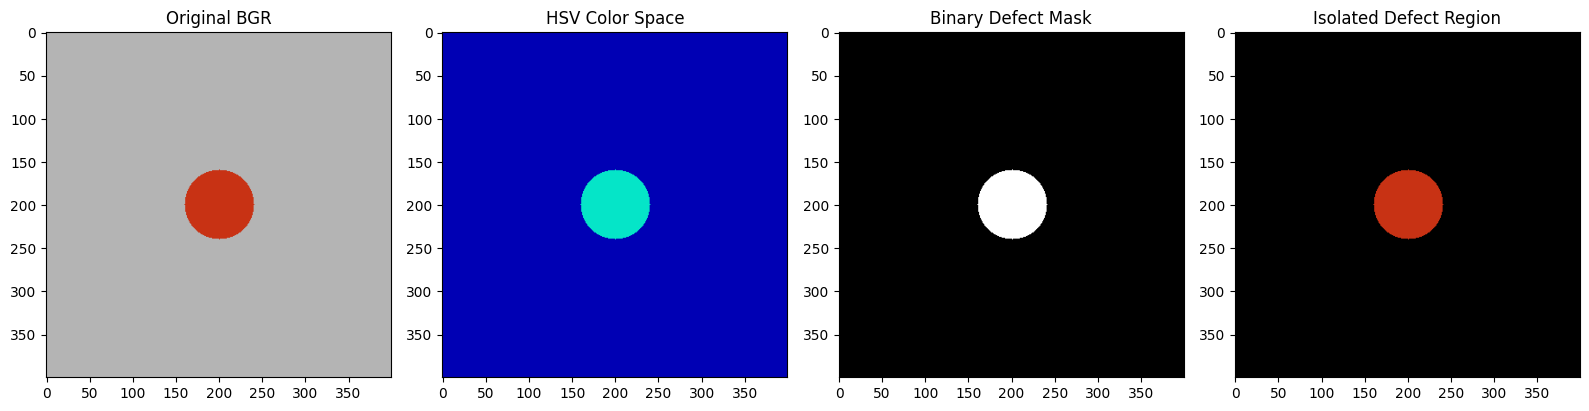


=== TASK 3: Medical Scan Edge Detection ===


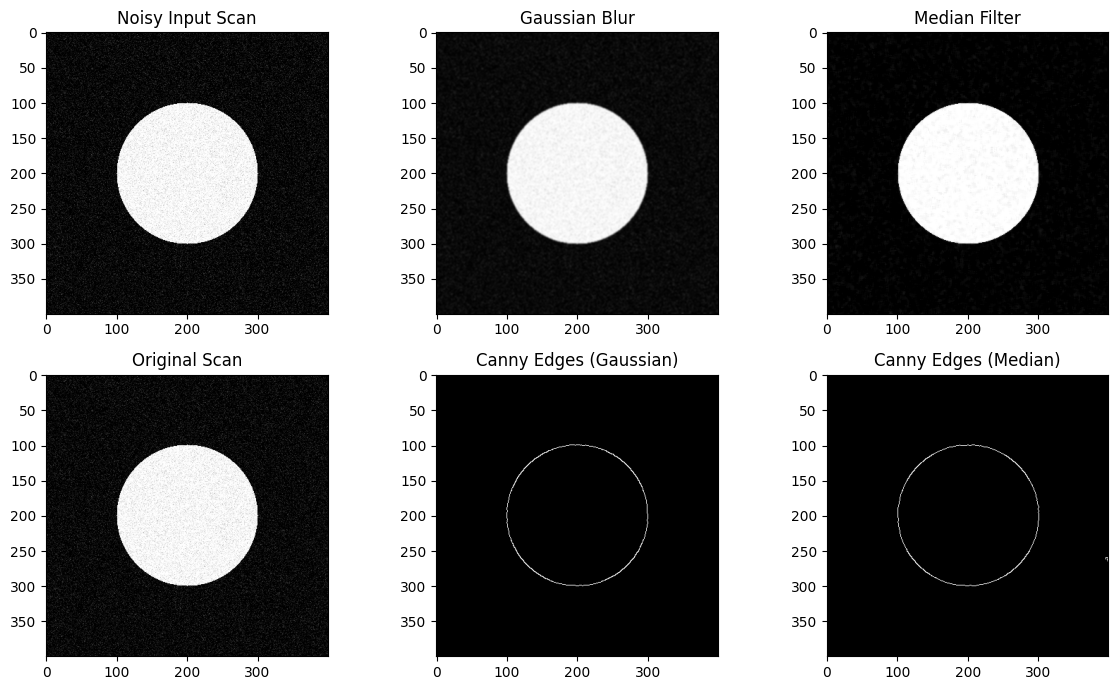


=== TASK 4 & 5: YOLO Inference & Person Filtering ===

image 1/1 /content/sample.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 314.0ms
Speed: 17.7ms preprocess, 314.0ms inference, 28.9ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/sample.jpg: 640x480 4 persons, 1 bus, 793.7ms
Speed: 4.5ms preprocess, 793.7ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
YOLOv8n Latency: 4991.10 ms | Detections: 6
YOLOv8m Latency: 1088.78 ms | Detections: 5


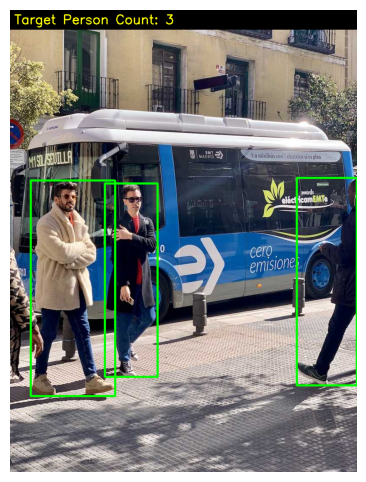


=== TASK 6: ROI Intrusion Alert ===


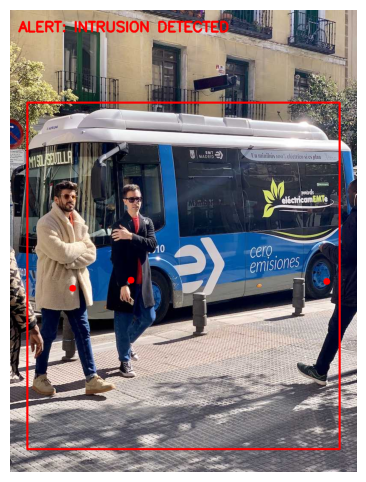

In [10]:
# ==========================================
# SETUP DEPENDENCIES & ENVIRONMENT
# ==========================================
!pip install -q ultralytics opencv-python matplotlib numpy

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from ultralytics import YOLO

os.makedirs("alerts", exist_ok=True)
os.makedirs("logs", exist_ok=True)

# Generate synthetic traffic image for testing
traffic_img = np.random.randint(50, 200, (800, 1200, 3), dtype=np.uint8)
cv2.imwrite("traffic.jpg", traffic_img)

# Fetch public test image containing COCO objects (bus, person, etc.)
!wget -q https://ultralytics.com/images/bus.jpg -O sample.jpg


# ==========================================
# TASK 1: TRAFFIC PREPROCESSING PIPELINE
# ==========================================
print("=== TASK 1: Image Preprocessing ===")
img_raw = cv2.imread("traffic.jpg")
img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

# Resize to 640x640 standard input shape
img_resized = cv2.resize(img_rgb, (640, 640), interpolation=cv2.INTER_LINEAR)

# Normalize range to [0.0, 1.0]
img_normalized = img_resized.astype(np.float32) / 255.0

print(f"Raw Image Shape:        {img_raw.shape}")
print(f"Preprocessed Tensor:    {img_normalized.shape}")
print(f"Pixel Range (Min/Max):  [{img_normalized.min():.2f}, {img_normalized.max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Traffic Image")
axes[1].imshow(img_normalized)
axes[1].set_title("Preprocessed Tensor (640x640 Normalized)")
plt.tight_layout()
plt.show()


# ==========================================
# TASK 2: INDUSTRIAL DEFECT DETECTION (HSV/LAB)
# ==========================================
print("\n=== TASK 2: Defect Isolation via Color Space ===")
metal_surface = np.full((400, 400, 3), 180, dtype=np.uint8)
cv2.circle(metal_surface, (200, 200), 40, (20, 50, 200), -1)  # Red defect target

hsv_img = cv2.cvtColor(metal_surface, cv2.COLOR_BGR2HSV)

# Mask isolation for red defect
lower_bound = np.array([0, 100, 100])
upper_bound = np.array([10, 255, 255])
binary_mask = cv2.inRange(hsv_img, lower_bound, upper_bound)
isolated_defect = cv2.bitwise_and(metal_surface, metal_surface, mask=binary_mask)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(metal_surface, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original BGR")
axes[1].imshow(hsv_img); axes[1].set_title("HSV Color Space")
axes[2].imshow(binary_mask, cmap='gray'); axes[2].set_title("Binary Defect Mask")
axes[3].imshow(cv2.cvtColor(isolated_defect, cv2.COLOR_BGR2RGB)); axes[3].set_title("Isolated Defect Region")
plt.tight_layout()
plt.show()


# ==========================================
# TASK 3: MEDICAL IMAGE EDGE DETECTION
# ==========================================
print("\n=== TASK 3: Medical Scan Edge Detection ===")
scan = np.zeros((400, 400), dtype=np.uint8)
cv2.circle(scan, (200, 200), 100, 255, -1)
noise = np.random.normal(0, 25, scan.shape).astype(np.int16)
noisy_scan = np.clip(scan.astype(np.int16) + noise, 0, 255).astype(np.uint8)

gauss_blur = cv2.GaussianBlur(noisy_scan, (5, 5), 0)
median_blur = cv2.medianBlur(noisy_scan, 5)

canny_gauss = cv2.Canny(gauss_blur, 50, 150)
canny_median = cv2.Canny(median_blur, 50, 150)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes[0,0].imshow(noisy_scan, cmap='gray'); axes[0,0].set_title("Noisy Input Scan")
axes[0,1].imshow(gauss_blur, cmap='gray'); axes[0,1].set_title("Gaussian Blur")
axes[0,2].imshow(median_blur, cmap='gray'); axes[0,2].set_title("Median Filter")

axes[1,0].imshow(noisy_scan, cmap='gray'); axes[1,0].set_title("Original Scan")
axes[1,1].imshow(canny_gauss, cmap='gray'); axes[1,1].set_title("Canny Edges (Gaussian)")
axes[1,2].imshow(canny_median, cmap='gray'); axes[1,2].set_title("Canny Edges (Median)")
plt.tight_layout()
plt.show()


# ==========================================
# TASK 4 & 5: YOLO BENCHMARKING & CLASS FILTERING
# ==========================================
print("\n=== TASK 4 & 5: YOLO Inference & Person Filtering ===")
model_nano = YOLO("yolov8n.pt")
model_med = YOLO("yolov8m.pt")

# Benchmark Nano vs Medium
t0 = time.time()
res_nano = model_nano("sample.jpg")[0]
latency_nano = (time.time() - t0) * 1000

t0 = time.time()
res_med = model_med("sample.jpg")[0]
latency_med = (time.time() - t0) * 1000

print(f"YOLOv8n Latency: {latency_nano:.2f} ms | Detections: {len(res_nano.boxes)}")
print(f"YOLOv8m Latency: {latency_med:.2f} ms | Detections: {len(res_med.boxes)}")

# Filter for Persons (COCO ID 0)
sample_img = cv2.imread("sample.jpg")
annotated_frame = sample_img.copy()
person_count = 0

for box in res_nano.boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    if cls_id == 0 and conf >= 0.50:
        person_count += 1
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 3)

# Banner Overlay
cv2.rectangle(annotated_frame, (0, 0), (annotated_frame.shape[1], 45), (0, 0, 0), -1)
cv2.putText(annotated_frame, f"Target Person Count: {person_count}", (10, 32),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 255), 2)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


# ==========================================
# TASK 6: ROI PERIMETER INTRUSION ANALYTICS
# ==========================================
print("\n=== TASK 6: ROI Intrusion Alert ===")
img_roi = cv2.imread("sample.jpg")
h, w, _ = img_roi.shape

# Define ROI polygon
roi_polygon = np.array([[int(w*0.05), int(h*0.2)], [int(w*0.95), int(h*0.2)],
                        [int(w*0.95), int(h*0.95)], [int(w*0.05), int(h*0.95)]], np.int32)

intrusion_detected = False
for box in res_nano.boxes:
    if int(box.cls[0]) == 0:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        centroid = (int((x1 + x2) / 2), int((y1 + y2) / 2))

        if cv2.pointPolygonTest(roi_polygon, centroid, False) >= 0:
            intrusion_detected = True
            cv2.circle(img_roi, centroid, 8, (0, 0, 255), -1)

# Status color: Red for intrusion, Green for secure
roi_color = (0, 0, 255) if intrusion_detected else (0, 255, 0)
cv2.polylines(img_roi, [roi_polygon], isClosed=True, color=roi_color, thickness=3)

status_str = "INTRUSION DETECTED" if intrusion_detected else "SECURE"
cv2.putText(img_roi, f"ALERT: {status_str}", (20, 50),
            cv2.FONT_HERSHEY_SIMPLEX, 1.1, roi_color, 3)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_roi, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

=== TASK 7 & 8: Webcam Snapshot Detection & Log Generation ===
Click the 'Capture Frame' button when the webcam video appears...


<IPython.core.display.Javascript object>

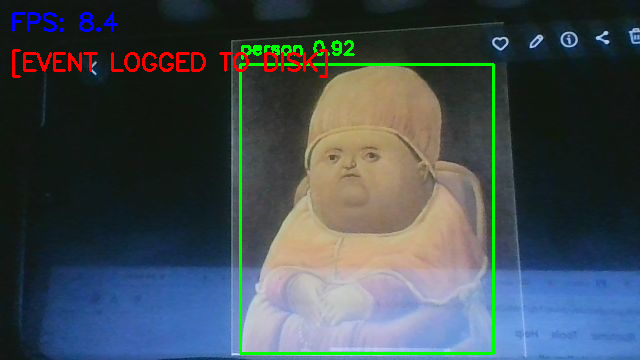


--- Event Log Output (logs/events.log) ---
20261004_181746,person,0.59,201,47,435,253
20261004_182138,person,0.74,173,52,402,298
20261004_182210,person,0.92,240,64,493,353



In [16]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
import time
import os
from ultralytics import YOLO

os.makedirs("alerts", exist_ok=True)
os.makedirs("logs", exist_ok=True)

# 1. JavaScript function to access browser webcam inside Colab
def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture Frame';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Wait for user click to capture frame
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# Helper for decoding base64 image data from JavaScript
from base64 import b64decode

print("=== TASK 7 & 8: Webcam Snapshot Detection & Log Generation ===")
print("Click the 'Capture Frame' button when the webcam video appears...")

try:
    # Capture webcam frame via browser
    image_file = take_photo()
    frame = cv2.imread(image_file)

    model = YOLO("yolov8n.pt")

    t0 = time.time()
    results = model(frame, verbose=False)[0]
    latency = (time.time() - t0) * 1000
    fps = 1000 / (latency + 1e-6)

    logging_triggered = False
    log_file = "logs/events.log"

    for box in results.boxes:
        conf = float(box.conf[0])
        cls_id = int(box.cls[0])
        cls_name = model.names[cls_id]

        # Draw bounding boxes
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(frame, f"{cls_name} {conf:.2f}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Log event on detection above 0.50 threshold
        if conf > 0.50:
            logging_triggered = True
            timestamp = time.strftime("%Y%m%d_%H%M%S")

            # Save snapshot
            cv2.imwrite(f"alerts/{timestamp}_{cls_name}.jpg", frame)

            # Append entry to log file
            with open(log_file, "a") as f:
                f.write(f"{timestamp},{cls_name},{conf:.2f},{x1},{y1},{x2},{y2}\n")

    # Render FPS counter & alert banner
    cv2.putText(frame, f"FPS: {fps:.1f}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    if logging_triggered:
        cv2.putText(frame, "[EVENT LOGGED TO DISK]", (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

    # Display dynamic output frame inside Colab
    cv2_imshow(frame)

    print("\n--- Event Log Output (logs/events.log) ---")
    if os.path.exists(log_file):
        with open(log_file) as f:
            print(f.read())

except Exception as e:
    print(f"Webcam capture skipped or unavailable: {e}")